# Capstone Project
## Image classifier for the SVHN dataset
### Instructions

In this notebook, you will create a neural network that classifies real-world images digits. You will use concepts from throughout this course in building, training, testing, validating and saving your Tensorflow classifier model.

This project is peer-assessed. Within this notebook you will find instructions in each section for how to complete the project. Pay close attention to the instructions as the peer review will be carried out according to a grading rubric that checks key parts of the project instructions. Feel free to add extra cells into the notebook as required.

### How to submit

When you have completed the Capstone project notebook, you will submit a pdf of the notebook for peer review. First ensure that the notebook has been fully executed from beginning to end, and all of the cell outputs are visible. This is important, as the grading rubric depends on the reviewer being able to view the outputs of your notebook. Save the notebook as a pdf (File -> Download as -> PDF via LaTeX). You should then submit this pdf for review.

### Let's get started!

We'll start by running some imports, and loading the dataset. For this project you are free to make further imports throughout the notebook as you wish. 

In [31]:
import tensorflow as tf
from scipy.io import loadmat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


![SVHN overview image](data/svhn_examples.jpg)
For the capstone project, you will use the [SVHN dataset](http://ufldl.stanford.edu/housenumbers/). This is an  image dataset of over 600,000 digit images in all, and is a harder dataset than MNIST as the numbers appear in the context of natural scene images. SVHN is obtained from house numbers in Google Street View images. 

* Y. Netzer, T. Wang, A. Coates, A. Bissacco, B. Wu and A. Y. Ng. "Reading Digits in Natural Images with Unsupervised Feature Learning". NIPS Workshop on Deep Learning and Unsupervised Feature Learning, 2011.

Your goal is to develop an end-to-end workflow for building, training, validating, evaluating and saving a neural network that classifies a real-world image into one of ten classes.

In [2]:
# Run this cell to load the dataset

train = loadmat('data/train_32x32.mat')
test = loadmat('data/test_32x32.mat')

Both `train` and `test` are dictionaries with keys `X` and `y` for the input images and labels respectively.

## 1. Inspect and preprocess the dataset
* Extract the training and testing images and labels separately from the train and test dictionaries loaded for you.
* Select a random sample of images and corresponding labels from the dataset (at least 10), and display them in a figure.
* Convert the training and test images to grayscale by taking the average across all colour channels for each pixel. _Hint: retain the channel dimension, which will now have size 1._
* Select a random sample of the grayscale images and corresponding labels from the dataset (at least 10), and display them in a figure.

In [3]:
# Extract images and labels
train_images = train['X']  # Shape: (32, 32, 3, num_samples)
train_labels = train['y']  # Shape: (num_samples, 1)

test_images = test['X']  # Shape: (32, 32, 3, num_samples)
test_labels = test['y']  # Shape: (num_samples, 1)

# Ensure labels are 0-9 instead of 1-10
train_labels[train_labels == 10] = 0
test_labels[test_labels == 10] = 0

# Print dataset shapes
print(f"Training Images Shape: {train_images.shape}")
print(f"Training Labels Shape: {train_labels.shape}")
print(f"Test Images Shape: {test_images.shape}")
print(f"Test Labels Shape: {test_labels.shape}")

Training Images Shape: (32, 32, 3, 73257)
Training Labels Shape: (73257, 1)
Test Images Shape: (32, 32, 3, 26032)
Test Labels Shape: (26032, 1)


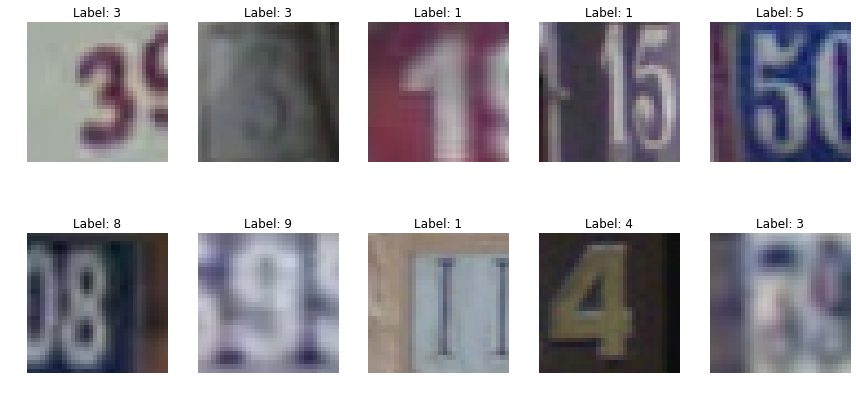

In [4]:
# Select random indices
num_samples = 10
random_indices = np.random.choice(train_images.shape[-1], num_samples, replace=False)

# Plot random samples
plt.figure(figsize=(12, 6))
for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[:, :, :, idx].astype(np.uint8))  # Convert to unsigned 8-bit integer
    plt.title(f"Label: {train_labels[idx][0]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [5]:
# Convert to grayscale
# Averaging across RGB channels and retaining channel dimension
train_images_gray = np.mean(train_images, axis=2, keepdims=True)
test_images_gray = np.mean(test_images, axis=2, keepdims=True)


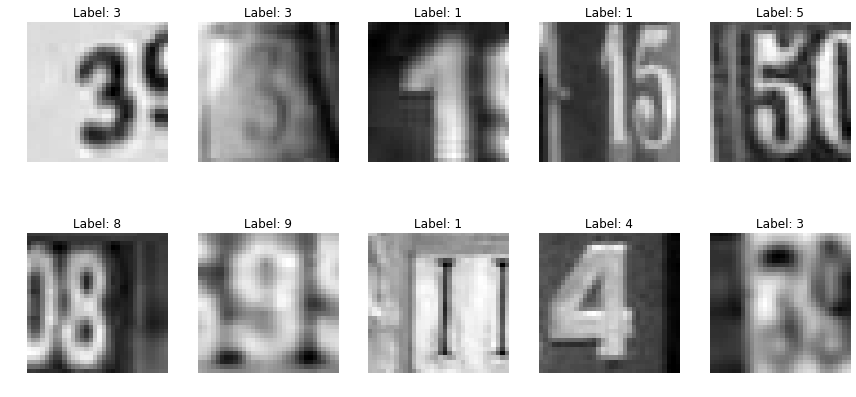

In [6]:
# Select random grayscale images
plt.figure(figsize=(12, 6))
for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images_gray[:, :, 0, idx], cmap='gray')  # Use grayscale colormap
    plt.title(f"Label: {train_labels[idx][0]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 2. MLP neural network classifier
* Build an MLP classifier model using the Sequential API. Your model should use only Flatten and Dense layers, with the final layer having a 10-way softmax output. 
* You should design and build the model yourself. Feel free to experiment with different MLP architectures. _Hint: to achieve a reasonable accuracy you won't need to use more than 4 or 5 layers._
* Print out the model summary (using the summary() method)
* Compile and train the model (we recommend a maximum of 30 epochs), making use of both training and validation sets during the training run. 
* Your model should track at least one appropriate metric, and use at least two callbacks during training, one of which should be a ModelCheckpoint callback.
* As a guide, you should aim to achieve a final categorical cross entropy training loss of less than 1.0 (the validation loss might be higher).
* Plot the learning curves for loss vs epoch and accuracy vs epoch for both training and validation sets.
* Compute and display the loss and accuracy of the trained model on the test set.

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [8]:
# Preprocess labels for one-hot encoding
train_labels_oh = tf.keras.utils.to_categorical(train_labels.flatten(), num_classes=10)
test_labels_oh = tf.keras.utils.to_categorical(test_labels.flatten(), num_classes=10)
# Split training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(train_images_gray.transpose(3, 0, 1, 2), 
                                                  train_labels_oh, test_size=0.2, random_state=42)


In [9]:

# Define the MLP model
model = Sequential([
    Flatten(input_shape=(32, 32, 1)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')  # 10 output classes
])

# Print model summary
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 1024)              0         
_________________________________________________________________
dense (Dense)                (None, 256)               262400    
_________________________________________________________________
dense_1 (Dense)              (None, 128)               32896     
_________________________________________________________________
dense_2 (Dense)              (None, 64)                8256      
_________________________________________________________________
dense_3 (Dense)              (None, 10)                650       
Total params: 304,202
Trainable params: 304,202
Non-trainable params: 0
_________________________________________________________________


In [10]:
# Compile the model
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

In [11]:
# Define callbacks
checkpoint_cb = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss')
early_stopping_cb = EarlyStopping(patience=5, restore_best_weights=True)

Train on 58605 samples, validate on 14652 samples
Epoch 1/5
58605/58605 [==============================] - 44s 759us/sample - loss: 5.8936 - accuracy: 0.1447 - val_loss: 2.7027 - val_accuracy: 0.2225
Epoch 2/5
58605/58605 [==============================] - 29s 492us/sample - loss: 2.1378 - accuracy: 0.2964 - val_loss: 1.8817 - val_accuracy: 0.3757
Epoch 3/5
58605/58605 [==============================] - 28s 482us/sample - loss: 1.6424 - accuracy: 0.4622 - val_loss: 1.6227 - val_accuracy: 0.4932
Epoch 4/5
58605/58605 [==============================] - 28s 482us/sample - loss: 1.4114 - accuracy: 0.5494 - val_loss: 1.4070 - val_accuracy: 0.5601
Epoch 5/5
58605/58605 [==============================] - 28s 476us/sample - loss: 1.3122 - accuracy: 0.5871 - val_loss: 1.2037 - val_accuracy: 0.6250


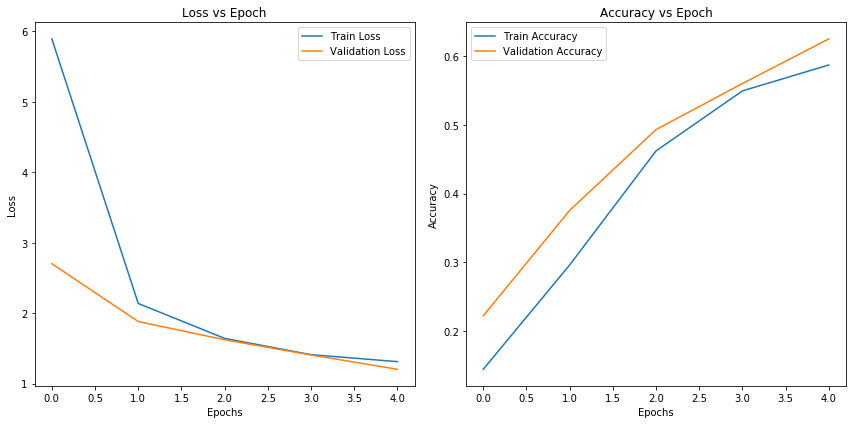

Test Loss: 1.3022
Test Accuracy: 0.6096


In [12]:

# Train the model
history = model.fit(X_train, y_train, 
                    validation_data=(X_val, y_val), 
                    epochs=5, 
                    batch_size=64, 
                    callbacks=[checkpoint_cb, early_stopping_cb])

# Plot training history
plt.figure(figsize=(12, 6))

# Loss vs Epoch
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy vs Epoch
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(test_images_gray.transpose(3, 0, 1, 2), test_labels_oh, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

## 3. CNN neural network classifier
* Build a CNN classifier model using the Sequential API. Your model should use the Conv2D, MaxPool2D, BatchNormalization, Flatten, Dense and Dropout layers. The final layer should again have a 10-way softmax output. 
* You should design and build the model yourself. Feel free to experiment with different CNN architectures. _Hint: to achieve a reasonable accuracy you won't need to use more than 2 or 3 convolutional layers and 2 fully connected layers.)_
* The CNN model should use fewer trainable parameters than your MLP model.
* Compile and train the model (we recommend a maximum of 30 epochs), making use of both training and validation sets during the training run.
* Your model should track at least one appropriate metric, and use at least two callbacks during training, one of which should be a ModelCheckpoint callback.
* You should aim to beat the MLP model performance with fewer parameters!
* Plot the learning curves for loss vs epoch and accuracy vs epoch for both training and validation sets.
* Compute and display the loss and accuracy of the trained model on the test set.

In [13]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential


In [14]:
# Define the CNN model
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    Flatten(),
    
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')  # 10 output classes
])


# Print model summary
cnn_model.summary()


Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 30, 30, 32)        320       
_________________________________________________________________
batch_normalization (BatchNo (None, 30, 30, 32)        128       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 15, 15, 32)        0         
_________________________________________________________________
dropout (Dropout)            (None, 15, 15, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 13, 13, 64)        18496     
_________________________________________________________________
batch_normalization_1 (Batch (None, 13, 13, 64)        256       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 6, 6, 64)         

In [15]:
# Compile the model
cnn_model.compile(optimizer='adam', 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])

In [16]:
# Define callbacks
cnn_checkpoint_cb = ModelCheckpoint('cnn_best_model.h5', save_best_only=True, monitor='val_loss')
cnn_early_stopping_cb = EarlyStopping(patience=5, restore_best_weights=True)


In [17]:
# Train the CNN model
cnn_history = cnn_model.fit(X_train, y_train, 
                            validation_data=(X_val, y_val), 
                            epochs=5, 
                            batch_size=64, 
                            callbacks=[cnn_checkpoint_cb, cnn_early_stopping_cb])




Train on 58605 samples, validate on 14652 samples
Epoch 1/5
58605/58605 [==============================] - 577s 10ms/sample - loss: 0.9739 - accuracy: 0.7000 - val_loss: 0.4655 - val_accuracy: 0.8602
Epoch 2/5
58605/58605 [==============================] - 572s 10ms/sample - loss: 0.5166 - accuracy: 0.8413 - val_loss: 0.3724 - val_accuracy: 0.8885
Epoch 3/5
58605/58605 [==============================] - 567s 10ms/sample - loss: 0.4473 - accuracy: 0.8653 - val_loss: 0.4119 - val_accuracy: 0.8795
Epoch 4/5
58605/58605 [==============================] - 570s 10ms/sample - loss: 0.4018 - accuracy: 0.8788 - val_loss: 0.3735 - val_accuracy: 0.8873
Epoch 5/5
58605/58605 [==============================] - 568s 10ms/sample - loss: 0.3702 - accuracy: 0.8892 - val_loss: 0.3059 - val_accuracy: 0.9103


<Figure size 864x432 with 0 Axes>

<Figure size 864x432 with 0 Axes>

In [32]:
# Plot training history
plt.figure(figsize=(12, 6))

<Figure size 864x432 with 0 Axes>

<Figure size 864x432 with 0 Axes>

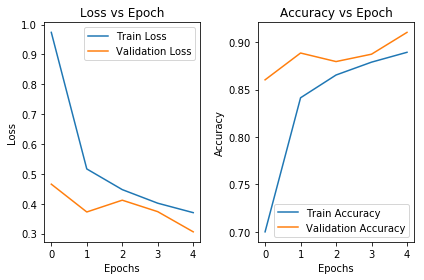

Test Loss: 0.3443
Test Accuracy: 0.8984


In [25]:
# Loss vs Epoch
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['loss'], label='Train Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy vs Epoch
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['accuracy'], label='Train Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate on test set
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(test_images_gray.transpose(3, 0, 1, 2), test_labels_oh, verbose=0)
print(f"Test Loss: {cnn_test_loss:.4f}")
print(f"Test Accuracy: {cnn_test_accuracy:.4f}")

## 4. Get model predictions
* Load the best weights for the MLP and CNN models that you saved during the training run.
* Randomly select 5 images and corresponding labels from the test set and display the images with their labels.
* Alongside the image and label, show each model’s predictive distribution as a bar chart, and the final model prediction given by the label with maximum probability.

In [26]:
import random

In [27]:
# Load the best weights for both models
mlp_model = model  # MLP model previously defined
mlp_model.load_weights('best_model.h5')

cnn_model.load_weights('cnn_best_model.h5')  # CNN model previously defined


In [28]:
# Select 5 random test samples
num_samples = 5
random_indices = random.sample(range(test_images_gray.shape[-1]), num_samples)

test_images_sample = test_images_gray[:, :, :, random_indices]
test_labels_sample = test_labels[random_indices].flatten()



In [29]:
# Generate predictions for the selected samples
mlp_predictions = mlp_model.predict(test_images_sample.transpose(3, 0, 1, 2))  # MLP model expects samples first
cnn_predictions = cnn_model.predict(test_images_sample.transpose(3, 0, 1, 2))  # CNN model expects samples first

# Visualize the results
plt.figure(figsize=(15, 10))

<Figure size 1080x720 with 0 Axes>

<Figure size 1080x720 with 0 Axes>

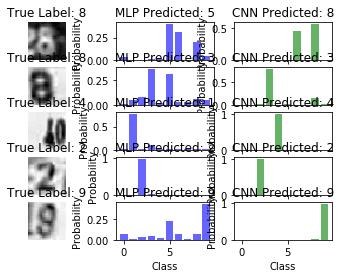

In [30]:
for i, idx in enumerate(random_indices):
    true_label = test_labels_sample[i]
    mlp_pred = mlp_predictions[i]
    cnn_pred = cnn_predictions[i]

    # Plot the image
    plt.subplot(num_samples, 3, 3 * i + 1)
    plt.imshow(test_images_sample[:, :, 0, i], cmap='gray')
    plt.title(f"True Label: {true_label}")
    plt.axis('off')

    # Plot MLP prediction probabilities
    plt.subplot(num_samples, 3, 3 * i + 2)
    plt.bar(range(10), mlp_pred, color='blue', alpha=0.6)
    plt.title(f"MLP Predicted: {np.argmax(mlp_pred)}")
    plt.xlabel("Class")
    plt.ylabel("Probability")

    # Plot CNN prediction probabilities
    plt.subplot(num_samples, 3, 3 * i + 3)
    plt.bar(range(10), cnn_pred, color='green', alpha=0.6)
    plt.title(f"CNN Predicted: {np.argmax(cnn_pred)}")
    plt.xlabel("Class")
    plt.ylabel("Probability")

plt.tight_layout()
plt.show()